In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

from pyhdas.frequency import spectrogram, add_db, power_spectrum
from pyhdas.aggregate import quantile
from pyhdas.aragon import concat_raw_data, aragon_select_files

In [2]:
def calculate_low_frequency_spectrum(
    strain,
    stride=16,
    low_frequency_cutoff=50,
    low_frequency_min=0.1,
):
    """Calculate low-frequency spectrum from strain signal

    Parameters
    ----------
    strain : xarray
        DAS strain measurement time series
    stride: integer, number of positions to calculate at once
        Using a higher stride will be faster on computers with a lot of RAM.
    low_frequency_cutoff : float, default 50
        Cutoff of the frequencies to discard when saving the low frequency
        outputs.
    low_frequency_min : float, default 0.1
        Minimal frequency for the power_spectrum of the low
        frequencies output

    Returns
    -------
    xarray
        low-frequency spectrum
    """

    all_spectra = []
    for j in range(0, len(strain.position), stride):
        low_freq_spectrum_ = power_spectrum(
            strain.isel(position=slice(j, j + stride)),
            min_frequency=low_frequency_min,
            keep_time_dim=True,
        )
        low_freq_spectrum_ = low_freq_spectrum_.sel(
            freq=slice(
                low_frequency_cutoff,
            )
        )
        all_spectra.append(low_freq_spectrum_)

    low_freq_spectrum = xr.concat(all_spectra, dim="position")

    return low_freq_spectrum

# Settings

In [3]:
dir_data = Path(r"data/19")
t_start = pd.Timestamp("2021-02-19 10:00:00+00")
t_end = pd.Timestamp("2021-02-19 10:02:00+00")
extension = "bin"

# Loading strain

In [4]:
file_list = list(aragon_select_files(dir_data, t_start, t_end, extension=extension))
ds_raw = concat_raw_data(file_list)
t_start = t_start.tz_localize(None)
t_end = t_end.tz_localize(None)
ds_raw = ds_raw.sel(time=slice(t_start, t_end))

In [ ]:
# Plot strain
fig,ax = plt.subplots(figsize=(12,6))
for pos in np.arange(4220, 4270, 10):
    ax.plot(ds_raw.time, ds_raw.sel(position=pos).strain, label=f"{pos}m")
ax.set_ylabel("strain [m/m]")
ax.legend(loc="best", fancybox=True, shadow=True)
ax.set_title("strain timeseries at multiple locations")
plt.show()

# Frequency analysis

In [ ]:
# Calculate spectrogram
ds_spect = spectrogram(ds_raw, variable='strain')

/var/lib/randd/.venv/lib64/python3.9/site-packages/pyhdas/frequency.py:139: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert new_dimension not in data.dims.keys(), (


In [5]:
# Calculate low frequency spectrogram
ds_lowfreq_spect = calculate_low_frequency_spectrum(ds_raw)

/var/lib/randd/.venv/lib64/python3.9/site-packages/pyhdas/frequency.py:139: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert new_dimension not in data.dims.keys(), (


/var/lib/randd/.venv/lib64/python3.9/site-packages/pyhdas/frequency.py:139: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert new_dimension not in data.dims.keys(), (
/var/lib/randd/.venv/lib64/python3.9/site-packages/pyhdas/frequency.py:139: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert new_dimension not in data.dims.keys(), (
/var/lib/randd/.venv/lib64/python3.9/site-packages/pyhdas/frequency.py:139: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a map

ValueError: Cannot specify both x and y kwargs for line plots.

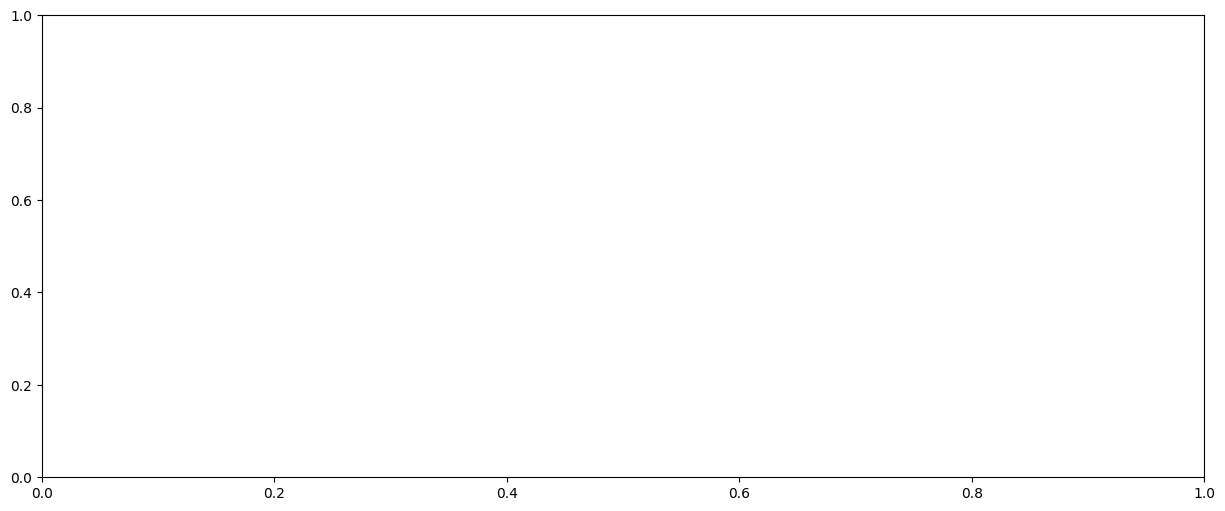

In [6]:
# Plot time spectrogram at a specific location
fig,ax = plt.subplots(figsize=(15,6))
ds_lowfreq_spect.Pxx_dB.sel(position=4240).plot(x="time", y="freq", ax=ax, vmin=-40, vmax=20, cmap="magma")
ax.set_title("time spectrogram for location 4240m")
plt.show()

In [ ]:
# Plot frequency spectrum at a specific location and timestamp
fig,ax = plt.subplots(figsize=(12,6))
da = ds_spect.sel(position=4240, time="2021-02-25 10:01:32")
ax.plot(da.freq, da.Pxx_dB)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("Pxx_dB [dB]")
ax.set_title(f"frequency spectrum at position 4240m at {da.time.values[0]}")
plt.show()

In [ ]:
# Plot position spectrogram for all positions at specific timestamp
fig,ax = plt.subplots(figsize=(15,6))
ds_spect.Pxx_dB.isel(time=0).plot(x="position", y="freq", ax=ax, vmin=-40, vmax=20, cmap="magma")
ax.set_title(f"position spectrogram at {ds_spect.time.values[0]}")
plt.show()

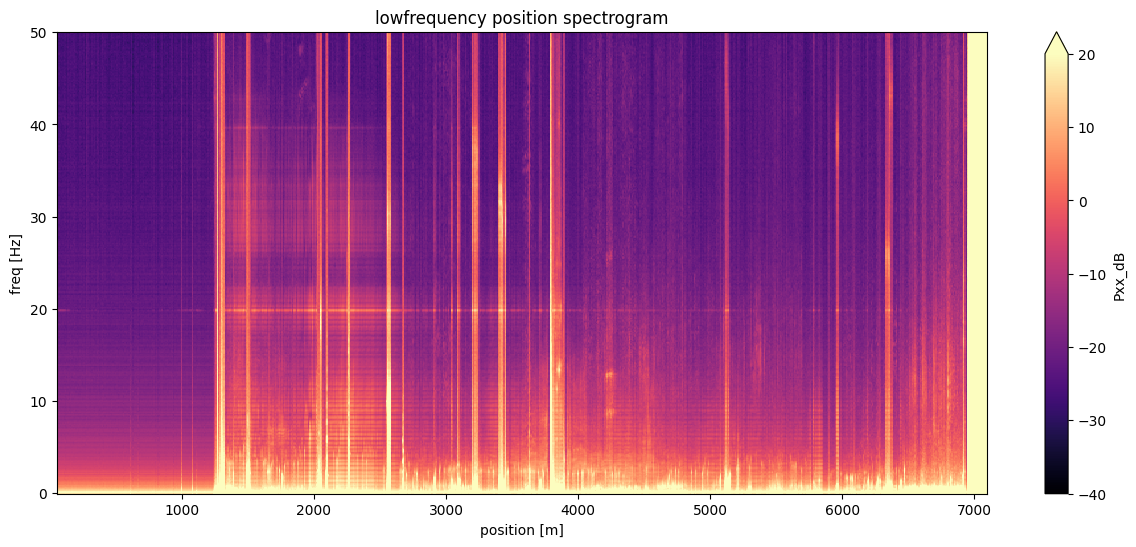

In [9]:
# Plot lowfrequency position spectrogram for al positions
fig,ax = plt.subplots(figsize=(15,6))
ds_lowfreq_spect.Pxx_dB.isel(time=0).plot(x="position", y="freq", ax=ax, vmin=-40, vmax=20, cmap="magma")
ax.set_title(f"lowfrequency position spectrogram")
plt.show()

In [ ]:
# Aggregate spectogram over time (e.g. pick the 10% quantile over time -> filters out sudden loud noises) 
ds_spect_quantile = ds_spect.reduce(func=lambda x, axis: np.nanquantile(x, q=0.1, axis=axis), dim="time")

In [ ]:
fig,ax = plt.subplots(figsize=(15,6))
ds_spect_quantile.Pxx_dB.plot(x="position", y="freq", ax=ax, vmin=-40, vmax=10, cmap="magma")
ax.set_title(f"frequency spectra aggregated (10% quantile) over 5min per position[dB]")
plt.show()

# Soundlevel analysis

In [ ]:
ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
ds_soundlevel = add_db(ds_soundlevel)

ds_soundlevel_high_pass = ds_spect[["Pxx"]].sel(freq=slice(100,1000)).sum(dim="freq")
ds_soundlevel_high_pass = add_db(ds_soundlevel_high_pass)

In [ ]:
# Plot soundlevel over time and all positions
fig,ax = plt.subplots(figsize=(15,6))
ds_soundlevel.Pxx_dB.plot(x="position", y="time", ax=ax, vmax = 40, cmap="magma")
ax.set_title(f"soundlevel [dB] over all frequencies")
plt.show()

In [ ]:
# Plot soundlevel timeseries at a selection of locations
fig,ax = plt.subplots(figsize=(12,6))
for pos in np.arange(4220, 4270, 10):
    ax.plot(ds_soundlevel.time, ds_soundlevel.sel(position=pos).Pxx_dB, label=f"{pos}m", alpha=0.5)
ax.legend(loc="best", fancybox=True, shadow=True)
ax.set_ylabel("Pxx_dB [dB]")
ax.set_title(f"soundlevel timeseries at multiple locations")
plt.show()

In [ ]:
# Plot high passed soundlevel over time and all positions -> filters out cars
fig,ax = plt.subplots(figsize=(15,6))
ds_soundlevel_high_pass.Pxx_dB.plot(x="position", y="time", ax=ax, vmax = 20, cmap="magma")
ax.set_title(f"high pass soundlevel [dB]")
plt.show()

# hvplot examples

In [ ]:
import hvplot.xarray

In [ ]:
ds_soundlevel.sel(position=slice(4220,4260)).hvplot(
    x="time", y="Pxx_dB", by="position", width=1200, height=600, title="soundlevel timeseries at multiple locations"
) # By clicking in the legend you can make positions transparent

In [ ]:
ds_soundlevel.Pxx_dB.hvplot(
    x="position", y="time", width=1200, height=600, clim=(None,40), cmap="magma", title="soundlevel [dB] over all frequencies"
)